**Lab3-GenAI-LLM: 06-ai-ethics-medicine.ipynb** (BMED365) | Priority: 1 (core)

_AI Ethics in Medicine – A practical guide to ethical considerations when deploying AI in healthcare_

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab3-GenAI-LLM/notebooks/06-ai-ethics-medicine.ipynb)

Last updated: 2026-01-18, A. Lundervold

Use the `bmed365-2026` conda environment or Google Colab

# AI Ethics in Medicine

**ELMED219 / BMED365 - Lab 3: Generative AI & Large Language Models**

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description |
|-----------|-------------|
| **Identify ethical challenges** | Recognize key ethical dilemmas when AI is applied in clinical contexts |
| **Understand bias types** | Explain historical, representation, measurement, and aggregation bias |
| **Evaluate privacy risks** | Assess privacy implications of cloud vs. local AI deployments |
| **Apply EU AI Act** | Classify medical AI systems by risk level and identify compliance requirements |
| **Analyze responsibility** | Determine how accountability is distributed among doctors, hospitals, and vendors |
| **Design ethical frameworks** | Use structured checklists for ethical assessment of AI systems |

### Prerequisites

- Basic understanding of AI/ML concepts (from previous notebooks)
- Familiarity with medical ethics principles (autonomy, beneficence, non-maleficence, justice)
- No programming experience required (all code is demonstrative)

### Clinical Relevance

As future healthcare professionals, you will increasingly encounter AI-based decision support tools. This notebook equips you with the critical thinking skills to:
- Evaluate whether an AI tool is appropriate for clinical use
- Communicate AI limitations to patients
- Advocate for ethical AI implementation in your workplace

## 📋 Contents

| Section | Topic | Key Concepts |
|---------|-------|--------------|
| **1** | [Ethical Challenges](#1-ethical-challenges) | Medical ethics principles, ethical dilemmas |
| **2** | [Bias in Medical AI](#2-bias-in-medical-ai) | Types of bias, real-world examples |
| **3** | [Privacy and Data Security](#3-privacy-and-data-security) | GDPR, LLM-specific concerns |
| **4** | [Regulation and EU AI Act](#4-regulation-and-eu-ai-act) | Risk classification, compliance requirements |
| **5** | [Responsibility and Decision-Making](#5-responsibility-and-decision-making) | Accountability, human-in-the-loop |
| **6** | [Best Practices](#6-best-practices) | Implementation guidelines |
| **7** | [Reflection Questions](#7-reflection-questions) | Self-assessment and discussion |
| **8** | [Glossary](#8-glossary-of-key-terms) | Key terminology |
| **9** | [Further Reading](#9-further-reading--resources) | References and resources |

In [14]:
# =============================================================================
# REPRODUCIBILITY SETTINGS
# =============================================================================
# This notebook uses minimal code for demonstration purposes.
# Setting random seeds ensures consistent visualizations across runs.

import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Configure matplotlib for consistent styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Environment configured")
print(f"🎲 Random seed set to {RANDOM_SEED} for reproducibility")
print("\n📚 This notebook focuses on concepts rather than implementation.")
print("   All code cells are for demonstration and visualization purposes.")

✅ Environment configured
🎲 Random seed set to 42 for reproducibility

📚 This notebook focuses on concepts rather than implementation.
   All code cells are for demonstration and visualization purposes.


---

## 1. Ethical Challenges

### 1.1 The Four Principles of Medical Ethics and AI

AI in healthcare raises fundamental ethical questions that touch upon the four classical principles of biomedical ethics (Beauchamp & Childress, 2019):

| Principle | Traditional Meaning | AI-Specific Challenge |
|----------|---------------------|----------------------|
| **Autonomy** | Respect patient's right to make informed decisions | Does the patient understand AI is being used? Can they opt out? Is consent meaningful? |
| **Beneficence** | Act in the patient's best interest | Does AI actually improve outcomes? What evidence supports its use? |
| **Non-maleficence** | "First, do no harm" | Can AI errors cause harm? Are failure modes understood? Who is accountable? |
| **Justice** | Fair distribution of resources and care | Is the AI equally accurate for all patient groups? Does it perpetuate inequities? |

> **💡 Key Insight:** These principles were developed for human decision-making. When AI mediates clinical decisions, we must re-examine how each principle applies in practice.

### 1.2 Ethical Dilemmas in Practice

The following cases illustrate real-world tensions between ethical principles. Consider how you would navigate each situation:

---

**Case 1: Resource Allocation** *(Justice vs. Beneficence)*

> An AI triage system predicts that patient A has an 80% chance of surviving intensive care, while patient B has a 40% chance. During a capacity crisis, should AI predictions determine ICU bed allocation?

| Consideration | Discussion Point |
|---------------|------------------|
| **Utilitarian view** | Maximize total lives saved → prioritize patient A |
| **Egalitarian view** | Equal right to care regardless of prognosis |
| **Historical concern** | What if the AI is less accurate for patient B's demographic? |

---

**Case 2: Autonomy vs. AI Recommendation** *(Autonomy vs. Beneficence)*

> A patient refuses the treatment recommended by an AI system, preferring an alternative the AI ranks as suboptimal. The physician agrees with the AI. How should patient autonomy be balanced against evidence-based AI recommendations?

---

**Case 3: The Black Box Problem** *(Transparency vs. Efficacy)*

> A deep learning model achieves 95% diagnostic accuracy, outperforming specialists at 87%. However, the model cannot explain its reasoning. Is it ethical to use a more accurate but unexplainable system?

---

**Case 4: Disclosure Dilemma** *(Transparency)*

> Hospital policy requires informing patients when AI assists in their care. A patient with severe anxiety asks, "Was a computer involved in my diagnosis?" Knowing full disclosure may increase their distress, how should you respond?

> **🤔 Think About It:** There are no "correct" answers to these dilemmas. The goal is to develop systematic reasoning about ethical trade-offs.

In [15]:
# =============================================================================
# ETHICAL ASSESSMENT FRAMEWORK FOR MEDICAL AI
# =============================================================================
# This framework provides a structured approach to evaluating AI systems
# before deployment in clinical settings. It is based on the ALTAI 
# (Assessment List for Trustworthy AI) by the European Commission and
# adapted for healthcare contexts.
#
# Usage: Before implementing any AI tool, review each question systematically
# with your clinical and technical teams.
# =============================================================================

def ethical_checklist(ai_system_name: str) -> dict:
    """
    Generate a comprehensive ethical checklist for evaluating a medical AI system.
    
    This checklist covers five key domains aligned with EU AI Act requirements
    and WHO guidance on AI ethics in healthcare.
    
    Parameters
    ----------
    ai_system_name : str
        Name or type of the AI system being evaluated (for documentation)
    
    Returns
    -------
    dict
        Dictionary with five categories, each containing assessment questions
        
    Example
    -------
    >>> checklist = ethical_checklist("Chest X-ray Pneumonia Detector")
    >>> print(checklist['Transparency'])
    """
    
    checklist = {
        # TRANSPARENCY: Can stakeholders understand the system?
        "Transparency": [
            "Is it clear to patients that AI is being used?",
            "Can the AI's decisions be explained in understandable terms?",
            "Is the training data documented and accessible for audit?",
            "Are the model's limitations clearly communicated?"
        ],
        
        # FAIRNESS: Does the system treat all groups equitably?
        "Fairness": [
            "Has the model been validated on diverse populations?",
            "Are there known biases in the training data?",
            "Is performance monitored separately across demographic groups?",
            "Are there mechanisms to detect and mitigate emerging bias?"
        ],
        
        # PRIVACY: Is patient data protected appropriately?
        "Privacy": [
            "How is patient data processed, stored, and transmitted?",
            "Has valid consent been obtained for AI-assisted care?",
            "What is the risk of re-identification from the data?",
            "Does data processing comply with GDPR/local regulations?"
        ],
        
        # ACCOUNTABILITY: Who is responsible when things go wrong?
        "Responsibility": [
            "Who is accountable when the AI makes an error?",
            "Is there meaningful human oversight of AI decisions?",
            "How are AI-assisted decisions logged for audit?",
            "Is there a clear appeals/override process?"
        ],
        
        # SAFETY: What happens when the system fails?
        "Safety": [
            "What are the failure modes and their clinical impact?",
            "Are there backup procedures when AI is unavailable?",
            "How is the model monitored for performance degradation?",
            "What is the process for updating or retraining the model?"
        ]
    }
    return checklist


# =============================================================================
# DEMONSTRATION: Generate and display the checklist
# =============================================================================

# Example: Evaluating a diagnostic support AI
system_name = "Diagnostic Support AI for Radiology"
checklist = ethical_checklist(system_name)

print("╔" + "═" * 59 + "╗")
print("║" + f" ETHICAL CHECKLIST FOR: {system_name}".ljust(58) + "║")
print("╚" + "═" * 59 + "╝")

for category, questions in checklist.items():
    print(f"\n📋 {category.upper()}")
    print("-" * 50)
    for i, question in enumerate(questions, 1):
        print(f"  □ {i}. {question}")

print("\n" + "=" * 60)
print("💡 TIP: Use this checklist in multidisciplinary team meetings")
print("   before deploying any AI system in clinical practice.")

╔═══════════════════════════════════════════════════════════╗
║ ETHICAL CHECKLIST FOR: Diagnostic Support AI for Radiology║
╚═══════════════════════════════════════════════════════════╝

📋 TRANSPARENCY
--------------------------------------------------
  □ 1. Is it clear to patients that AI is being used?
  □ 2. Can the AI's decisions be explained in understandable terms?
  □ 3. Is the training data documented and accessible for audit?
  □ 4. Are the model's limitations clearly communicated?

📋 FAIRNESS
--------------------------------------------------
  □ 1. Has the model been validated on diverse populations?
  □ 2. Are there known biases in the training data?
  □ 3. Is performance monitored separately across demographic groups?
  □ 4. Are there mechanisms to detect and mitigate emerging bias?

📋 PRIVACY
--------------------------------------------------
  □ 1. How is patient data processed, stored, and transmitted?
  □ 2. Has valid consent been obtained for AI-assisted care?
  □ 3.

---

## 2. Bias in Medical AI

### 2.1 Understanding Algorithmic Bias

Bias in AI systems can lead to **systematically unfair treatment** of patient groups. Unlike random errors that affect everyone equally, bias creates **predictable patterns of harm** that often affect already vulnerable populations.

> **⚠️ Critical Point:** AI bias is not just a technical problem—it is a health equity issue with real consequences for patients.

### 2.2 Types of Bias in Healthcare AI

| Type | Definition | Healthcare Example | Stage |
|------|------------|-------------------|-------|
| **Historical Bias** | Training data encodes past societal inequities | Women historically underdiagnosed for heart disease → model learns this pattern | Data collection |
| **Representation Bias** | Certain groups underrepresented in training data | Dermatology datasets with <5% darker skin tones | Data collection |
| **Measurement Bias** | Data quality differs across groups | Pulse oximeters overestimate O₂ in dark skin; different diagnostic criteria by gender | Measurement |
| **Aggregation Bias** | Single model ignores meaningful subgroup differences | One diabetes risk model for all ages/ethnicities | Model design |
| **Evaluation Bias** | Test data not representative of deployment population | Model tested in academic centers, deployed in rural clinics | Validation |
| **Deployment Bias** | Model used differently than intended | Screening tool used for diagnosis | Implementation |

### 2.3 The Bias Pipeline

```
Data Collection → Feature Engineering → Model Training → Evaluation → Deployment
     ↓                    ↓                   ↓             ↓            ↓
 Historical &        Measurement         Aggregation   Evaluation    Deployment
Representation         Bias                Bias          Bias          Bias
    Bias
```

> **💡 Key Insight:** Bias can enter at ANY stage of the AI pipeline. Addressing it requires vigilance throughout the entire process.

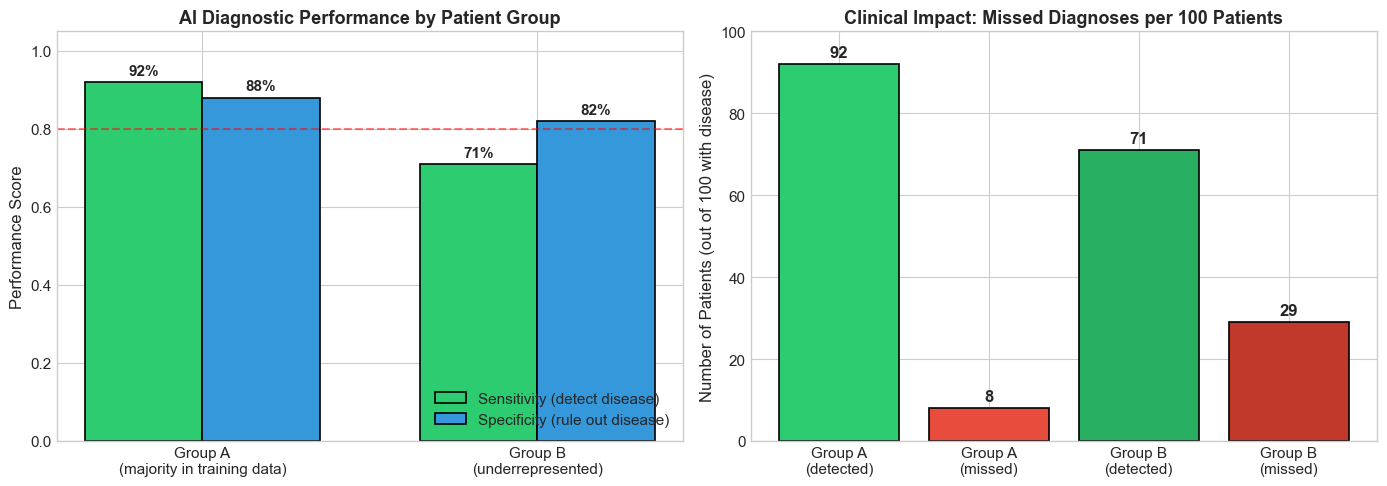


📊 CLINICAL INTERPRETATION

  ⚠️  Sensitivity gap: 21 percentage points

  Per 100 patients with disease:
      • Group A: 8 missed diagnoses
      • Group B: 29 missed diagnoses

  🔴 Group B patients are 3.6x more likely to have
     their disease missed by this AI system.

  This is algorithmic bias with direct patient harm implications.


In [16]:
# =============================================================================
# VISUALIZATION: Differential Model Performance Across Patient Groups
# =============================================================================
# This visualization demonstrates a common pattern in medical AI: models that
# perform well on average may have significantly worse performance for
# underrepresented groups. Values are based on published research showing
# real disparities in AI diagnostic tools.
#
# Clinical Context: A 21% difference in sensitivity means that for every
# 100 patients with disease, 21 more patients in the minority group will
# receive false negative results (missed diagnoses).
# =============================================================================

def simulate_bias_example():
    """
    Simulate performance metrics for an AI model across patient groups.
    
    This example illustrates a common finding in medical AI research:
    models trained predominantly on one demographic group often perform
    worse on underrepresented populations.
    
    Returns
    -------
    tuple
        (group_labels, sensitivity_values, specificity_values)
        
    References
    ----------
    Based on patterns observed in:
    - Obermeyer et al. (2019) Science: Racial bias in healthcare algorithms
    - Adamson & Smith (2018) JAMA Derm: Skin cancer detection disparities
    """
    groups = ['Group A\n(majority in training data)', 
              'Group B\n(underrepresented)']
    
    # Performance metrics (proportion of correct classifications)
    # Sensitivity = True Positive Rate (detecting disease when present)
    # Specificity = True Negative Rate (ruling out disease when absent)
    sensitivity = [0.92, 0.71]  # 21 percentage point gap
    specificity = [0.88, 0.82]  # 6 percentage point gap
    
    return groups, sensitivity, specificity


# Generate the visualization
groups, sens, spec = simulate_bias_example()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: Bar chart comparison ---
ax1 = axes[0]
x = np.arange(len(groups))
width = 0.35

bars1 = ax1.bar(x - width/2, sens, width, label='Sensitivity (detect disease)', 
                color='#2ecc71', edgecolor='black', linewidth=1.2)
bars2 = ax1.bar(x + width/2, spec, width, label='Specificity (rule out disease)', 
                color='#3498db', edgecolor='black', linewidth=1.2)

ax1.set_ylabel('Performance Score', fontsize=12)
ax1.set_title('AI Diagnostic Performance by Patient Group', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(groups, fontsize=11)
ax1.legend(loc='lower right')
ax1.set_ylim(0, 1.05)
ax1.axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='Minimum acceptable')

# Add value labels on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax1.annotate(f'{height:.0%}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Right panel: Clinical impact visualization ---
ax2 = axes[1]

# Simulate 100 patients with disease per group
n_patients = 100
detected_a = int(sens[0] * n_patients)
missed_a = n_patients - detected_a
detected_b = int(sens[1] * n_patients)
missed_b = n_patients - detected_b

categories = ['Group A\n(detected)', 'Group A\n(missed)', 
              'Group B\n(detected)', 'Group B\n(missed)']
values = [detected_a, missed_a, detected_b, missed_b]
colors = ['#2ecc71', '#e74c3c', '#27ae60', '#c0392b']

bars = ax2.bar(categories, values, color=colors, edgecolor='black', linewidth=1.2)
ax2.set_ylabel('Number of Patients (out of 100 with disease)', fontsize=12)
ax2.set_title('Clinical Impact: Missed Diagnoses per 100 Patients', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 100)

# Add value labels
for bar, val in zip(bars, values):
    ax2.annotate(f'{val}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print clinical interpretation
print("\n" + "=" * 70)
print("📊 CLINICAL INTERPRETATION")
print("=" * 70)
print(f"\n  ⚠️  Sensitivity gap: {(sens[0]-sens[1])*100:.0f} percentage points")
print(f"\n  Per 100 patients with disease:")
print(f"      • Group A: {missed_a} missed diagnoses")
print(f"      • Group B: {missed_b} missed diagnoses")
print(f"\n  🔴 Group B patients are {missed_b/max(missed_a,1):.1f}x more likely to have")
print(f"     their disease missed by this AI system.")
print("\n  This is algorithmic bias with direct patient harm implications.")
print("=" * 70)

### 2.4 Real-World Examples of Bias in Medical AI

The following are documented cases of algorithmic bias with patient safety implications:

| Domain | Finding | Impact | Reference |
|--------|---------|--------|----------|
| **Skin Cancer Detection** | Dermatology AI trained on 90%+ light-skinned images | Reduced accuracy for melanoma detection in patients with darker skin | Adamson & Smith, JAMA Dermatol 2018 |
| **Pulse Oximetry** | Overestimates O₂ saturation by 2-3% in Black patients | Missed hypoxemia during COVID-19 pandemic; delayed treatment | Sjoding et al., NEJM 2020 |
| **Pain Assessment** | Historical data reflects undertreatment of pain in minorities | AI perpetuates disparities in analgesic prescribing | Obermeyer et al., Science 2019 |
| **Cardiovascular Risk** | Heart disease presents atypically in women | Models trained on male-dominant data underpredict risk in women | Vogel et al., Lancet 2021 |
| **Healthcare Utilization** | Algorithm used healthcare costs as proxy for health needs | Black patients assigned lower risk scores despite being sicker | Obermeyer et al., Science 2019 |

> **🔬 The Obermeyer Study (2019):** A widely-used healthcare algorithm affected ~70 million patients annually. It used healthcare costs as a proxy for health needs, but Black patients systematically had lower costs due to reduced access to care. As a result, Black patients had to be significantly sicker to receive the same risk score and equivalent care as white patients.

### 2.5 Self-Check: Identifying Bias ✓

Before proceeding, consider these questions:

1. **Why might historical data reflect societal inequities?**
   <details>
   <summary>💡 Click for guidance</summary>
   
   Historical data captures past practices, including periods when certain groups had less access to care, were underdiagnosed, or were excluded from research. The AI learns from these patterns as if they were medically valid.
   </details>

2. **How would you test a dermatology AI for bias before deployment?**
   <details>
   <summary>💡 Click for guidance</summary>
   
   - Evaluate performance stratified by Fitzpatrick skin type (I-VI)
   - Ensure test dataset includes diverse representation
   - Set minimum performance thresholds for each subgroup
   - Conduct prospective validation in diverse clinical settings
   </details>

---

## 3. Privacy and Data Security

### 3.1 Why Health Data is Special

Health data is among the **most sensitive personal information** and requires special protection. Unlike other data, health information:

- Can reveal conditions that carry social stigma
- May affect insurance, employment, and personal relationships
- Cannot be changed (unlike passwords or financial data)
- Has lifelong relevance to the individual

### 3.2 GDPR and Health Data

Under the EU General Data Protection Regulation (GDPR), health data is classified as a **"special category"** under Article 9, requiring enhanced protections:

| Requirement | Description | Practical Implication |
|------------|-------------|----------------------|
| **Explicit Consent** | Clear, affirmative agreement for specific purpose | "I agree to AI-assisted analysis" is not enough—specify what AI, what purpose |
| **Legal Basis** | Consent OR other lawful basis (e.g., vital interests) | Clinical care may use "legitimate interest" but research typically needs consent |
| **Data Minimization** | Only collect data necessary for the purpose | AI should not access full patient record if only imaging is needed |
| **Purpose Limitation** | Data used only for stated purpose | Data collected for diagnosis cannot automatically be used to train AI |
| **Right to Access** | Patients can request their data | Includes AI-derived insights about them |
| **Right to Erasure** | "Right to be forgotten" (with exceptions) | May conflict with medical record retention requirements |

> **⚖️ Legal Note:** GDPR applies whenever processing data of EU residents, regardless of where the processor is located. Norwegian institutions must also comply with national health data regulations.

In [17]:
# =============================================================================
# PRIVACY RISK ASSESSMENT FRAMEWORK
# =============================================================================
# This tool helps clinical teams evaluate privacy implications of different
# AI deployment architectures. The choice between cloud and local deployment
# involves significant trade-offs that must be carefully considered.
#
# Context: In 2023-2024, several healthcare organizations faced scrutiny for
# sending patient data to commercial LLM providers without adequate safeguards.
# =============================================================================

def privacy_risk_assessment(scenario: str) -> dict:
    """
    Generate a privacy risk assessment for a given AI deployment scenario.
    
    This assessment is based on guidance from:
    - Norwegian Data Protection Authority (Datatilsynet)
    - European Data Protection Board (EDPB)
    - HIPAA Security Rule (for comparison)
    
    Parameters
    ----------
    scenario : str
        Deployment type: 'cloud_service', 'local_model', or 'hybrid'
    
    Returns
    -------
    dict
        Contains description, risk_level, risks, and mitigation_measures
    """
    
    scenarios = {
        "cloud_service": {
            "description": "AI runs on external cloud infrastructure (e.g., OpenAI, Google Cloud)",
            "risk_level": "HIGH",
            "color": "🔴",
            "risks": [
                "Patient data transmitted outside organizational control",
                "Third-party vendor employees may access data",
                "Data may be stored in non-EU/EEA jurisdictions",
                "Data may be used to train vendor's models (data leakage)",
                "Vendor's terms of service may change unilaterally",
                "Difficulty ensuring right to erasure"
            ],
            "mitigation_measures": [
                "Execute Data Processing Agreement (DPA) per GDPR Art. 28",
                "Verify data residency in EU/EEA (not just EU company)",
                "Require end-to-end encryption + at-rest encryption",
                "Contractually prohibit use of data for model training",
                "Implement data anonymization/pseudonymization before transmission",
                "Regular vendor security audits (SOC 2, ISO 27001)",
                "Consider federated learning alternatives"
            ]
        },
        "local_model": {
            "description": "AI runs entirely on hospital/institutional infrastructure",
            "risk_level": "MEDIUM",
            "color": "🟡",
            "risks": [
                "Internal access control complexity",
                "Logging and auditability requirements",
                "Model update and maintenance burden",
                "Limited computational resources may affect performance",
                "Insider threat risk"
            ],
            "mitigation_measures": [
                "Implement role-based access control (RBAC)",
                "Comprehensive audit logging of all AI queries",
                "Secure, tested update and patching procedures",
                "Physical and network security controls",
                "Staff training on data handling",
                "Regular penetration testing"
            ]
        },
        "hybrid": {
            "description": "Sensitive processing local, non-sensitive in cloud",
            "risk_level": "MEDIUM-HIGH",
            "color": "🟠",
            "risks": [
                "Complexity of determining what is 'sensitive'",
                "Data leakage at integration points",
                "Inconsistent security policies",
                "Audit trail fragmentation"
            ],
            "mitigation_measures": [
                "Clear data classification policy",
                "Secure API design with minimal data exposure",
                "Unified logging across environments",
                "Regular architecture security reviews"
            ]
        }
    }
    return scenarios.get(scenario, {})


# =============================================================================
# DEMONSTRATION: Compare deployment scenarios
# =============================================================================

print("╔" + "═" * 68 + "╗")
print("║" + " PRIVACY RISK ASSESSMENT: AI DEPLOYMENT SCENARIOS".center(68) + "║")
print("╚" + "═" * 68 + "╝")

for scenario_key in ["cloud_service", "local_model", "hybrid"]:
    info = privacy_risk_assessment(scenario_key)
    
    print(f"\n{info['color']} {info['description'].upper()}")
    print(f"   Risk Level: {info['risk_level']}")
    print("-" * 70)
    
    print("   ⚠️  RISKS:")
    for risk in info['risks']:
        print(f"       • {risk}")
    
    print("\n   ✅ MITIGATION MEASURES:")
    for measure in info['mitigation_measures']:
        print(f"       • {measure}")

print("\n" + "=" * 70)
print("💡 RECOMMENDATION: For patient-identifiable data, local deployment with")
print("   strict access controls is generally preferred. Cloud services require")
print("   robust contractual, technical, and organizational safeguards.")
print("=" * 70)

╔════════════════════════════════════════════════════════════════════╗
║          PRIVACY RISK ASSESSMENT: AI DEPLOYMENT SCENARIOS          ║
╚════════════════════════════════════════════════════════════════════╝

🔴 AI RUNS ON EXTERNAL CLOUD INFRASTRUCTURE (E.G., OPENAI, GOOGLE CLOUD)
   Risk Level: HIGH
----------------------------------------------------------------------
   ⚠️  RISKS:
       • Patient data transmitted outside organizational control
       • Third-party vendor employees may access data
       • Data may be stored in non-EU/EEA jurisdictions
       • Data may be used to train vendor's models (data leakage)
       • Vendor's terms of service may change unilaterally
       • Difficulty ensuring right to erasure

   ✅ MITIGATION MEASURES:
       • Execute Data Processing Agreement (DPA) per GDPR Art. 28
       • Verify data residency in EU/EEA (not just EU company)
       • Require end-to-end encryption + at-rest encryption
       • Contractually prohibit use of data for

### 3.3 Special Considerations for Large Language Models (LLMs)

LLMs like GPT-4, Claude, and Med-PaLM introduce **unique privacy challenges** that traditional AI risk frameworks may not adequately address:

| Issue | Description | Clinical Example |
|-------|-------------|------------------|
| **Memorization** | LLMs can memorize and verbatim reproduce training data | Model might output a patient's name/condition if similar case was in training data |
| **Prompt Injection** | Malicious inputs can manipulate model behavior | Attacker tricks model into revealing other users' prompts |
| **Training Data Opacity** | Unknown what data was used to train the model | Medical misinformation in training data → harmful outputs |
| **API Logging** | Cloud providers may log all prompts/responses | Every patient query potentially stored by third party |
| **Context Window Leakage** | Information from one session influencing another | In shared systems, patient A's data appearing in patient B's response |

### 3.4 Practical Guidelines for LLM Use in Healthcare

```
┌─────────────────────────────────────────────────────────────────────┐
│  ✅ ACCEPTABLE                    │  ❌ AVOID                       │
├───────────────────────────────────┼─────────────────────────────────┤
│  • General medical questions      │  • Including patient names      │
│  • Literature summaries           │  • Specific case details        │
│  • Educational content            │  • Identifiable health data     │
│  • Anonymized case discussions    │  • Images with patient info     │
│  • Draft clinical documentation   │  • Real medical record numbers  │
│    (review before use!)           │  • Precise dates + locations    │
└───────────────────────────────────┴─────────────────────────────────┘
```

> **⚠️ Important:** Even with "enterprise" versions of LLMs that claim not to use data for training, you should assume all prompts are logged and potentially accessible. Never input truly sensitive information.

### 3.5 Self-Check: Privacy Considerations ✓

<details>
<summary>💡 A colleague wants to use ChatGPT to help draft a patient discharge summary. What should you advise?</summary>

**Guidance:**
1. ❌ Never paste the actual patient record into ChatGPT
2. ✅ Instead, create a fully anonymized/fictional case based on the general pattern
3. ✅ Use the output as a starting template, then customize with real details locally
4. ✅ Always verify the output for accuracy before clinical use
5. ⚖️ Check your institution's policy on AI tool usage
</details>

---

## 4. Regulation and EU AI Act

### 4.1 Overview: The EU AI Act (2024)

The **EU AI Act** is the world's first comprehensive AI regulation, entering into force in August 2024 with phased implementation through 2027. It establishes a **risk-based framework** that classifies AI systems by their potential for harm.

> **📅 Timeline:**
> - August 2024: Regulation enters into force
> - February 2025: Prohibitions on unacceptable-risk AI apply
> - August 2025: Requirements for general-purpose AI models apply
> - August 2026: Full requirements for high-risk AI apply

### 4.2 Risk-Based Classification

```
┌─────────────────────────────────────────────────────────────────────┐
│  🔴 UNACCEPTABLE RISK (PROHIBITED)                                  │
│  ─────────────────────────────────────────────────────────────────  │
│  • Social scoring by governments                                    │
│  • Exploiting vulnerabilities (age, disability)                     │
│  • Real-time biometric ID in public spaces (with exceptions)        │
│  • Emotion recognition in workplace/education                       │
│  These AI applications are BANNED in the EU.                        │
├─────────────────────────────────────────────────────────────────────┤
│  🟠 HIGH RISK                                                       │
│  ─────────────────────────────────────────────────────────────────  │
│  • Medical devices and diagnostics                                  │
│  • Critical infrastructure (energy, transport, water)               │
│  • Educational and vocational training assessment                   │
│  • Employment, worker management, recruitment                       │
│  • Essential services (banking, insurance, emergency)               │
│  → STRICT requirements: conformity assessment, documentation,       │
│    human oversight, risk management, data governance                │
├─────────────────────────────────────────────────────────────────────┤
│  🟡 LIMITED RISK                                                    │
│  ─────────────────────────────────────────────────────────────────  │
│  • Chatbots, virtual assistants                                     │
│  • Deepfakes, AI-generated content                                  │
│  • Emotion recognition (non-prohibited contexts)                    │
│  → TRANSPARENCY requirements: Users must know they interact with AI │
├─────────────────────────────────────────────────────────────────────┤
│  🟢 MINIMAL RISK                                                    │
│  ─────────────────────────────────────────────────────────────────  │
│  • AI-enabled video games                                           │
│  • Spam filters                                                     │
│  • Inventory management                                             │
│  → No specific requirements (existing law applies)                  │
└─────────────────────────────────────────────────────────────────────┘
```

### 4.3 Requirements for High-Risk AI Systems

**Most medical AI falls under HIGH-RISK classification**, requiring compliance with extensive obligations:

| Requirement | Description | Healthcare Implementation |
|------------|-------------|---------------------------|
| **Risk Management** | Continuous risk identification and mitigation | Clinical risk assessment; adverse event monitoring |
| **Data Governance** | Training data must be relevant, representative, error-free | Bias audits; data quality documentation |
| **Technical Documentation** | Detailed system documentation | Model cards; validation reports |
| **Record-Keeping** | Automatic logging of system operation | Audit trails of AI-assisted decisions |
| **Transparency** | Clear information for users | Patient disclosure; clinician training |
| **Human Oversight** | Humans can intervene and override | Override mechanisms; not fully autonomous |
| **Accuracy & Robustness** | Appropriate levels of reliability | Performance benchmarks; cybersecurity measures |

### 4.4 Implications for Healthcare Professionals

As a healthcare professional using AI, you should:

1. **Know the classification** of AI tools you use (likely high-risk)
2. **Expect documentation** from vendors about AI system capabilities and limitations
3. **Maintain oversight** – you can always override AI recommendations
4. **Report issues** through established adverse event channels
5. **Document AI-assisted decisions** in patient records

> **💡 Key Point:** The EU AI Act reinforces that **humans remain responsible** for clinical decisions. AI is a tool that supports, not replaces, professional judgment.

---

## 5. Responsibility and Decision-Making

### 5.1 The Accountability Gap

When AI makes or contributes to an error in healthcare, **who is legally and ethically responsible?** This question has no simple answer, and current legal frameworks are still adapting.

> **🤔 The Dilemma:** If a physician follows an incorrect AI recommendation and the patient is harmed, is the physician negligent for trusting the AI, or is the AI vendor liable for a defective product?

### 5.2 Distribution of Responsibility

| Actor | Potential Responsibilities | Relevant Framework |
|-------|---------------------------|-------------------|
| **Physician** | Clinical judgment; appropriate AI use; informed consent; override when needed | Medical malpractice law; professional standards |
| **Hospital/Institution** | System selection; implementation; training staff; monitoring performance | Organizational liability; duty of care |
| **AI Vendor** | Product safety; accurate documentation; post-market surveillance | Product liability; EU AI Act obligations |
| **Data Controller** | Data quality; lawful processing; privacy protection | GDPR; health data regulations |
| **Regulator** | Certification; market surveillance | CE marking; notified bodies |

### 5.3 The Physician's Position

Current consensus holds that **the physician retains ultimate clinical responsibility**, even when using AI tools. This is because:

1. **AI as Tool, Not Colleague:** Like imaging equipment or lab tests, AI provides information that the physician must interpret
2. **Professional Standards:** Medical ethics require independent judgment, not blind deference to any source
3. **Legal Precedent:** Courts have historically held physicians responsible for integrating various inputs into care decisions

However, this creates a **practical dilemma:**
- If AI is more accurate than the physician in specific tasks, should the physician override it?
- If the physician cannot understand the AI's reasoning, can they meaningfully oversee it?

### 5.4 Human-in-the-Loop: Principles and Challenges

**Human-in-the-Loop (HITL)** is a core principle of responsible AI, mandating that humans maintain meaningful control. In healthcare:

| Principle | Requirement | Challenge |
|-----------|-------------|----------|
| **Override Authority** | Clinician can reject AI recommendation | Automation bias: tendency to follow AI |
| **Explainability** | Clinician understands basis for recommendation | Many high-performing models are "black boxes" |
| **Opt-Out** | Patient/clinician can choose not to use AI | May not be practical if AI is integrated into workflow |
| **Auditability** | Decisions can be reviewed and traced | Requires comprehensive logging infrastructure |

### 5.5 Practical Recommendations for Clinicians

```
┌──────────────────────────────────────────────────────────────────────┐
│  WHEN USING AI-ASSISTED DECISION SUPPORT                             │
│  ────────────────────────────────────────────────────────────────    │
│                                                                      │
│  1. ✅ Verify you understand what the AI is designed to do           │
│  2. ✅ Know the AI's validation evidence and limitations             │
│  3. ✅ Integrate AI output with your clinical judgment               │
│  4. ✅ Document when you follow OR override AI recommendations       │
│  5. ✅ Report unexpected AI behaviors or errors                      │
│  6. ✅ Ensure patient is informed about AI use (as appropriate)      │
│                                                                      │
│  Remember: YOU are the healthcare professional. AI is your tool.     │
└──────────────────────────────────────────────────────────────────────┘
```

### 5.6 Self-Check: Responsibility ✓

<details>
<summary>💡 Scenario: An AI correctly identifies a lung nodule that the radiologist missed. The radiologist documented that they did not see the nodule. Who is responsible for the delay in diagnosis?</summary>

**Analysis:**
- The **radiologist** followed their standard process and made a human error (miss rate for nodules is 20-30%)
- The **AI** correctly detected the finding
- The **hospital** implemented AI but may not have clear protocols for integrating AI findings
- Key question: Was the AI output reviewed? Was there a protocol requiring review of AI findings?

**Takeaway:** Clear institutional policies must define:
1. When and how AI outputs are reviewed
2. How discrepancies between AI and clinician are resolved
3. Documentation requirements for AI-assisted interpretations
</details>

---

## 6. Best Practices

### 6.1 Framework for Ethical AI Implementation

The following framework integrates guidance from WHO, IEEE, and the European Commission to provide actionable best practices across the AI lifecycle:

```
┌─────────────────────────────────────────────────────────────────────┐
│                    AI IMPLEMENTATION LIFECYCLE                      │
│                                                                     │
│  PLANNING    →    DEVELOPMENT    →    DEPLOYMENT    →    MONITORING │
│     │                  │                  │                  │      │
│     ▼                  ▼                  ▼                  ▼      │
│  Ethical           Bias &            Training &         Performance │
│  Assessment        Privacy           Integration         & Safety   │
│  & Governance      Review            Planning            Monitoring │
└─────────────────────────────────────────────────────────────────────┘
```

### 6.2 Phase-by-Phase Best Practices

#### Phase 1: Before Implementation

| Action | Details | Responsible Party |
|--------|---------|-------------------|
| **Ethical Assessment** | Use structured checklist (Section 1); involve diverse stakeholders | Ethics committee; clinical leadership |
| **Bias Testing** | Validate performance across demographic subgroups | AI team; clinical experts |
| **Privacy Review** | DPIA (Data Protection Impact Assessment); GDPR compliance | Data protection officer; legal |
| **Responsibility Matrix** | Define who is accountable for what | Hospital administration |
| **Clinical Validation** | Evidence that AI works in your context | Clinical research team |

#### Phase 2: During Deployment

| Action | Details | Responsible Party |
|--------|---------|-------------------|
| **User Training** | Ensure clinicians understand capabilities AND limitations | Education department |
| **Integration Testing** | AI works correctly in clinical workflow | IT; clinical champions |
| **Override Procedures** | Clear process to reject AI recommendations | Clinical leadership |
| **Logging & Audit Trails** | All AI-assisted decisions documented | IT; compliance |

#### Phase 3: Ongoing Monitoring

| Action | Details | Responsible Party |
|--------|---------|-------------------|
| **Performance Monitoring** | Track accuracy, bias, and clinical outcomes | Quality improvement |
| **Adverse Event Reporting** | Report AI-related incidents | Clinical staff; risk management |
| **Model Updates** | Revalidate after any model changes | AI team; clinical validation |
| **User Feedback** | Regular surveys; incident debriefs | Clinical leadership |

### 6.3 Communicating with Patients About AI

| Do | Don't |
|----|-------|
| ✅ "AI technology helps us analyze your scan more thoroughly" | ❌ "The computer will diagnose you" |
| ✅ "Your doctor makes the final decision" | ❌ "AI is always right" |
| ✅ "You can ask questions about how AI is used" | ❌ "You don't need to worry about it" |
| ✅ "AI helps detect things humans might miss" | ❌ "AI replaces doctors" |
| ✅ Be honest about limitations | ❌ Oversell AI capabilities |

> **💬 Sample Script:** "We use AI software that assists our team in analyzing [test/image/data]. This helps us be more thorough, but your doctor reviews everything and makes all clinical decisions. Do you have any questions about this?"

---

## 7. Reflection Questions

### 🤔 For Discussion and Self-Assessment

The following questions are designed to deepen your understanding and prepare you for ethical challenges you may face as a healthcare professional. Consider discussing these with colleagues or in study groups.

#### Clinical Decision-Making

1. **An AI system recommends a different diagnosis than your clinical impression. The AI has 95% accuracy in studies, but you are 80% confident in your assessment. What factors would influence whether you follow the AI or your judgment?**

   <details>
   <summary>💡 Discussion Points</summary>
   
   Consider:
   - Quality of the validation evidence for the AI
   - Whether your specific patient population was represented in AI training
   - The clinical stakes (screening vs. diagnosis; benign vs. serious condition)
   - Your experience level with this type of case
   - Availability of additional tests/information
   </details>

2. **A patient asks you directly: "Was a computer involved in my diagnosis?" How would you respond, and what information would you share?**

3. **You notice that the AI system seems to perform differently for patients from a specific ethnic group. What steps would you take?**

#### Institutional Considerations

4. **Your hospital is considering implementing a new AI-based triage system. What questions would you want answered before supporting its adoption?**

5. **A colleague dismisses AI ethics concerns, saying "If it improves outcomes, that's all that matters." How would you respond?**

#### Future Perspectives

6. **As AI becomes more capable, should the standard of care evolve to require AI use in certain contexts? What are the implications?**

7. **How might AI change the physician-patient relationship in the next 10-20 years? What should we preserve?**

---

## 8. Glossary of Key Terms

### Ethics and Governance

| Term | Definition |
|------|------------|
| **Autonomy** | Ethical principle respecting patients' right to make informed decisions about their care |
| **Beneficence** | Ethical principle requiring healthcare actions that benefit the patient |
| **Non-maleficence** | Ethical principle to "first, do no harm" |
| **Justice** | Ethical principle requiring fair distribution of healthcare resources and treatment |
| **Informed Consent** | Patient agreement to treatment after receiving adequate information about risks and benefits |
| **Human-in-the-Loop** | System design ensuring humans maintain oversight and can override AI decisions |

### Bias and Fairness

| Term | Definition |
|------|------------|
| **Algorithmic Bias** | Systematic errors in AI that create unfair outcomes for certain groups |
| **Historical Bias** | Bias arising from training data that reflects past societal inequities |
| **Representation Bias** | Bias due to underrepresentation of certain groups in training data |
| **Measurement Bias** | Bias from inconsistent data collection methods across groups |
| **Aggregation Bias** | Bias from using one model for populations with meaningfully different characteristics |
| **Fairness** | Equitable AI performance across different patient populations |

### Privacy and Security

| Term | Definition |
|------|------------|
| **GDPR** | General Data Protection Regulation – EU law governing personal data processing |
| **Special Category Data** | GDPR classification for sensitive data including health information |
| **Data Processing Agreement (DPA)** | Contract governing how a processor handles personal data |
| **Pseudonymization** | Replacing identifying data with codes while maintaining re-identification ability |
| **Anonymization** | Irreversibly removing identifying information from data |
| **Data Minimization** | Principle of collecting only data necessary for the stated purpose |

### Regulation and Compliance

| Term | Definition |
|------|------------|
| **EU AI Act** | European regulation establishing a legal framework for AI based on risk levels |
| **High-Risk AI** | AI systems requiring strict compliance measures under EU AI Act (includes medical AI) |
| **Conformity Assessment** | Process to demonstrate AI system meets regulatory requirements |
| **CE Marking** | Certification indicating product meets EU safety, health, and environmental requirements |
| **Post-Market Surveillance** | Ongoing monitoring of AI systems after deployment |

### Technical Terms

| Term | Definition |
|------|------------|
| **Black Box** | AI system whose internal decision-making process is not transparent or explainable |
| **Explainability (XAI)** | Ability to understand and articulate how an AI reaches its decisions |
| **Sensitivity** | True positive rate – proportion of actual positives correctly identified |
| **Specificity** | True negative rate – proportion of actual negatives correctly identified |
| **Validation** | Process of testing AI performance on data not used in training |
| **Generalization** | Ability of an AI model to perform well on new, unseen data |

---

## 🎯 Key Takeaways

### What You Should Remember

```
╔══════════════════════════════════════════════════════════════════════╗
║                    CORE MESSAGES FROM THIS NOTEBOOK                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. ETHICAL PRINCIPLES APPLY TO AI                                   ║
║     Autonomy, beneficence, non-maleficence, and justice must be      ║
║     re-examined when AI mediates clinical decisions.                 ║
║                                                                      ║
║  2. BIAS IS A HEALTH EQUITY ISSUE                                    ║
║     AI can perpetuate or amplify existing disparities. Testing       ║
║     across demographic groups is essential before deployment.        ║
║                                                                      ║
║  3. PRIVACY REQUIRES ACTIVE MANAGEMENT                               ║
║     Health data needs special protection. Cloud services require     ║
║     robust contractual and technical safeguards.                     ║
║                                                                      ║
║  4. REGULATION IS EVOLVING RAPIDLY                                   ║
║     The EU AI Act classifies medical AI as high-risk with strict     ║
║     requirements for documentation, testing, and oversight.          ║
║                                                                      ║
║  5. HUMANS REMAIN RESPONSIBLE                                        ║
║     Clinicians retain ultimate responsibility for clinical           ║
║     decisions. AI is a tool that supports, not replaces, judgment.   ║
║                                                                      ║
║  6. STRUCTURED ASSESSMENT IS ESSENTIAL                               ║
║     Use checklists and frameworks to systematically evaluate         ║
║     AI systems before and during clinical deployment.                ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
```

### Learning Objectives: Self-Assessment

Review the learning objectives from the start of this notebook:

| Objective | Check Your Understanding |
|-----------|-------------------------|
| ✅ Identify ethical challenges | Can you explain how each medical ethics principle applies to AI? |
| ✅ Understand bias types | Can you name and describe 4+ types of AI bias? |
| ✅ Evaluate privacy risks | Can you compare cloud vs. local AI deployment risks? |
| ✅ Apply EU AI Act | Can you classify a medical AI as prohibited/high/limited/minimal risk? |
| ✅ Analyze responsibility | Can you describe the accountability distribution for an AI error? |
| ✅ Design ethical frameworks | Can you use the ethical checklist for a new AI system? |

### What's Next?

- **Notebook 07:** Trustworthy AI – Building reliable AI systems
- **Practice:** Apply the ethical checklist to a real-world medical AI example
- **Explore:** The EU AI Act official documentation and WHO AI ethics guidance

---

## 9. Further Reading & Resources

### 📚 Key References

#### Foundational Texts

| Resource | Description |
|----------|-------------|
| **Beauchamp & Childress (2019)** | *Principles of Biomedical Ethics* (8th ed.) – The foundational text for medical ethics |
| **Topol, E. (2019)** | *Deep Medicine* – How AI can make healthcare human again |
| **O'Neil, C. (2016)** | *Weapons of Math Destruction* – How algorithms can perpetuate inequality |

#### Landmark Research Papers

| Paper | Key Finding |
|-------|-------------|
| **Obermeyer et al. (2019)** Science | Racial bias in healthcare algorithm affecting millions |
| **Sjoding et al. (2020)** NEJM | Pulse oximetry accuracy disparities by race |
| **Adamson & Smith (2018)** JAMA Dermatol | Skin cancer AI and skin tone diversity issues |
| **Rajpurkar et al. (2022)** Nature Medicine | AI vs. physicians in medical diagnosis |

#### Regulatory & Guidance Documents

| Document | Source |
|----------|--------|
| **EU AI Act** | [Official EUR-Lex text](https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32024R1689) |
| **Ethics and Governance of AI for Health** | [WHO 2021 Guidance](https://www.who.int/publications/i/item/9789240029200) |
| **ALTAI Assessment List** | [European Commission](https://digital-strategy.ec.europa.eu/en/library/assessment-list-trustworthy-artificial-intelligence-altai-self-assessment) |
| **FDA AI/ML-Based SaMD** | [FDA Guidance](https://www.fda.gov/medical-devices/software-medical-device-samd) |

### 🌐 Online Resources

| Resource | URL | Description |
|----------|-----|-------------|
| AI Now Institute | [ainowinstitute.org](https://ainowinstitute.org) | Research on social implications of AI |
| Partnership on AI | [partnershiponai.org](https://partnershiponai.org) | Multi-stakeholder AI ethics organization |
| Algorithm Watch | [algorithmwatch.org](https://algorithmwatch.org) | Tracking and analyzing algorithmic decision-making |
| Montreal AI Ethics Institute | [montrealethics.ai](https://montrealethics.ai) | AI ethics research and education |

### 📖 Recommended Reading for Medical Students

For a deeper dive into specific topics covered in this notebook:

1. **On Bias:** Obermeyer Z, et al. "Dissecting racial bias in an algorithm used to manage the health of populations." *Science* 2019;366:447-453.

2. **On Privacy:** Price WN, Cohen IG. "Privacy in the age of medical big data." *Nature Medicine* 2019;25:37-43.

3. **On Regulation:** Gerke S, et al. "The need for a system view to regulate artificial intelligence/machine learning-based software as medical device." *NPJ Digital Medicine* 2020;3:53.

4. **On Clinical Implementation:** Kelly CJ, et al. "Key challenges for delivering clinical impact with artificial intelligence." *BMC Medicine* 2019;17:195.

---

*Next notebook: [07 - Trustworthy AI](07-trustworthy-ai.ipynb)*

---

**Notebook Information:**
- **Course:** ELMED219 / BMED365
- **Lab:** Lab 3 - Generative AI & Large Language Models
- **Author:** A. Lundervold
- **Last Updated:** 2026-01-18
- **License:** CC BY-SA 4.0